# 01. Import libraries

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 02. Import data

In [6]:
# Import pkl data 
path = '/Users/bobbi/Careerfoundry/InstacartBasketAnalysis_01_25'

ords_prods_merge = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared data', 'ords_prods_grouping_8.pkl'))

In [7]:
ords_prods_merge.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,existing_merge,...,prices,_merge,busiest_days,busiest_period_of_day,max_order,loyalty_flag,mean_price,spending_flag,median_ords,ords_flag
0,2539329,1,1,2,8,NaN,196,1,0,both,...,9.0,both,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
1,2539329,1,1,2,8,NaN,14084,2,0,both,...,12.5,both,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
2,2539329,1,1,2,8,NaN,12427,3,0,both,...,4.4,both,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
3,2539329,1,1,2,8,NaN,26088,4,0,both,...,4.7,both,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
4,2539329,1,1,2,8,NaN,26405,5,0,both,...,1.0,both,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer


# 03. Creating visualizations

### Bar Charts

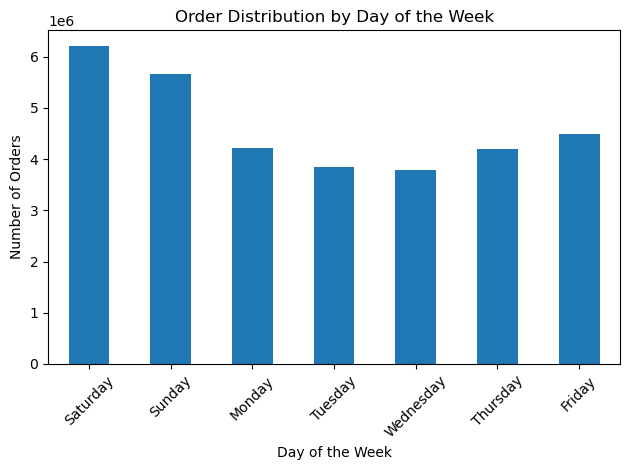

In [100]:
# Map each number to the corresponding day of the week
day_map = {
    0: 'Saturday',
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday'
}

# Creating bar charts
bar = ords_prods_merge['orders_day_of_week'].value_counts().sort_index().plot.bar()

# Set the x-tick labels to be the days of the week
bar.set_xticklabels([day_map[i] for i in bar.get_xticks()])

# Set labels and title
plt.title('Order Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
# Exporting charts
bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_orders_dow.png'))

### Histograms and scatterplots

<Axes: ylabel='Frequency'>

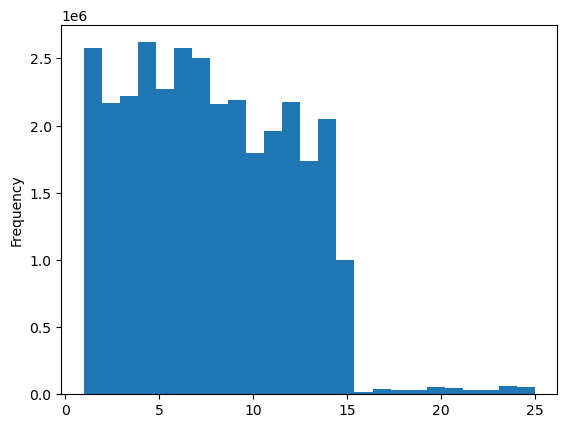

In [13]:
# Histograms and Scatterplots
ords_prods_merge['prices'].plot.hist(bins=25)

<Axes: xlabel='prices', ylabel='prices'>

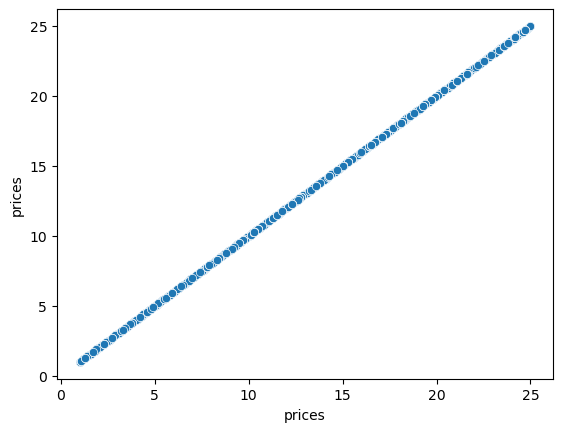

In [14]:
# Scatterplot
sns.scatterplot(x = 'prices', y='prices', data=ords_prods_merge)

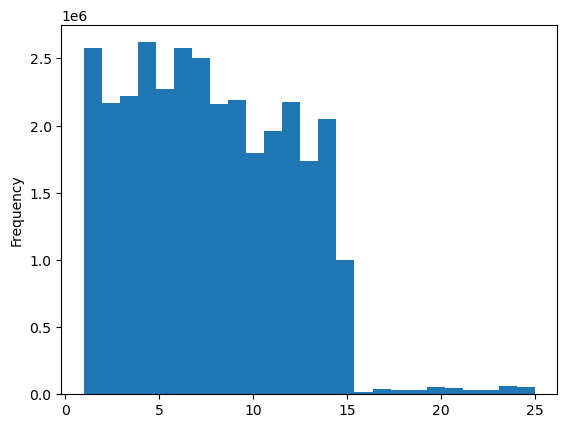

In [15]:
hist = ords_prods_merge['prices'].plot.hist(bins=25)

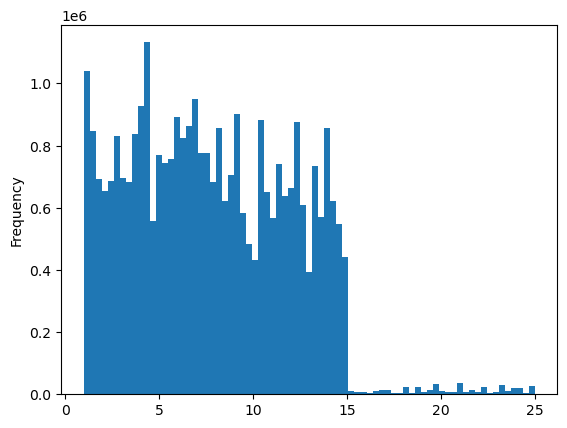

In [16]:
hist_2 = ords_prods_merge['prices'].plot.hist(bins=75)

In [17]:
# Export histograms
hist_2.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_orders_dow.png'))

In [18]:
hist.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'hist_prices.png'))

### Line Charts

In [20]:
# Line Charts with sample data

np.random.seed(4)

dev = np.random.rand(len(ords_prods_merge)) <= 0.7

In [21]:
dev

array([False,  True, False, ...,  True,  True,  True])

In [22]:
# Random sample (70)
big = ords_prods_merge[dev]

In [23]:
# Random sample (30)
small = ords_prods_merge[~dev]

In [24]:
# Check sample data 
len(ords_prods_merge)

32404859

In [25]:
len(big) + len(small)

32404859

In [26]:
# Create a sample data frame
df_2 = small[['orders_day_of_week', 'prices']]

In [27]:
df_2.head()

,orders_day_of_week,prices
0,2,9.0
2,2,4.4
3,2,4.7
6,3,3.0
10,3,4.0


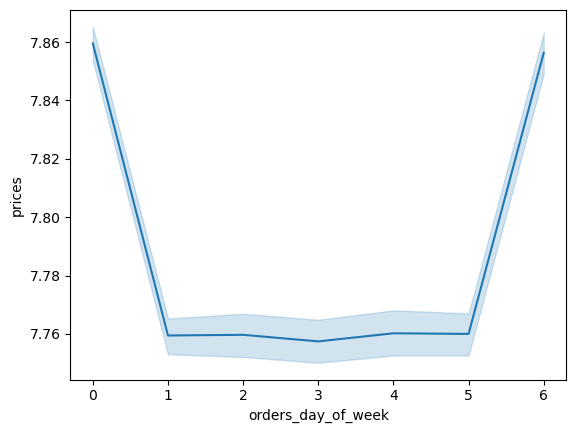

In [28]:
# Create line charts
line = sns.lineplot(data = df_2, x = 'orders_day_of_week', y = 'prices')

In [29]:
# Check bid data sample
df_4 = ords_prods_merge[['orders_day_of_week', 'prices']]

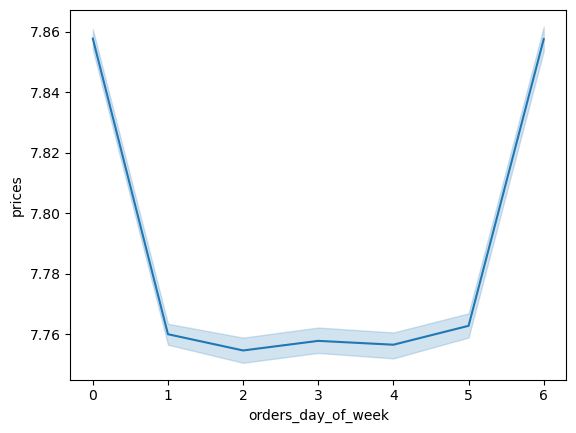

In [30]:
# The computer is not able to create this visualization
line_2 = sns.lineplot(data=df_4, x='orders_day_of_week', y='prices')

# 04. Orders and products visualizations

### Sales histogram

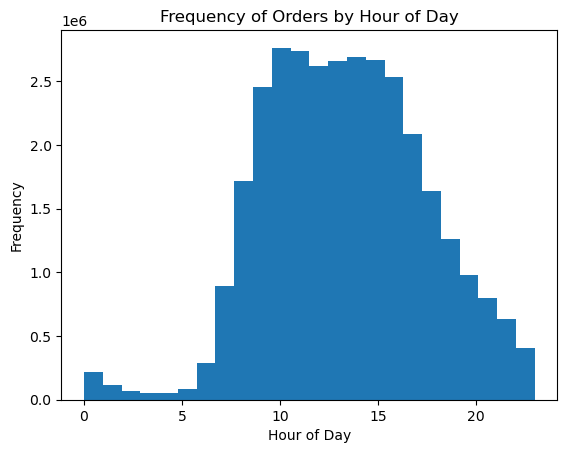

In [33]:
# Create an histogram of the 'order_hour_of_day'
hist_order = ords_prods_merge['order_hour_of_day'].plot.hist(bins=24)
plt.title('Frequency of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.show()

The histogram shows that peak hours are from 10AM to 10PM. The least busy time is grom midnight to 6 in the morning. From 7AM orders increase untill reaching the peak hours and after 16PM it starts to decrease until midninght. 

This histogram show a very typical customer behaviour for an online grocery store, where most user order groceries during the day to get them in the afternoon. It aligns their ordering with regular daily routines too. This can help Instacart prepare for this rush hour by:
* Hiring more delivery drivers
* Hiring more warehouse staff during this hours

The hours between midnight and 7AM are typically sleeping hours for most people. 
It can be that orders decline in the afternoon because people order same day groceries and the Instacart doesn't have the capacity to offer same day delivery after certain hours. The company could address this with some pre-ordering sales or reduce cost of delivery for orders that are not the same day, as well as promotions targeted to quiter hours.

### Loyalty bar chart

In [36]:
# Number of customer in each category
ords_prods_merge.groupby('loyalty_flag')['user_id'].nunique()

loyalty_flag
Loyal customer       17017
New customer        112328
Regular customer     76864
Name: user_id, dtype: int64

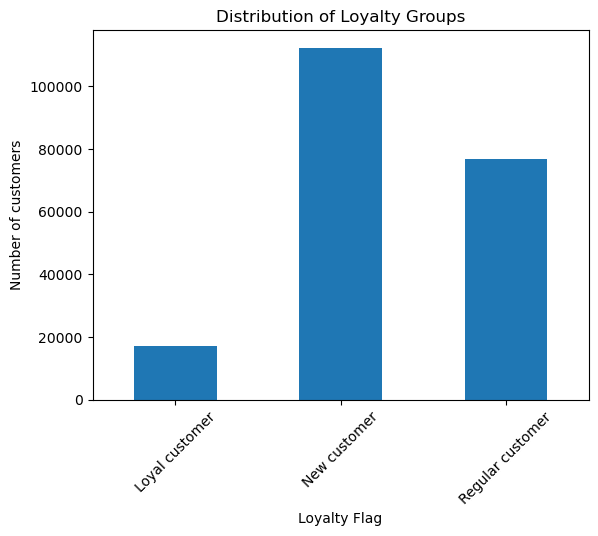

In [37]:
# Bar chart
bar_loyalty = ords_prods_merge.groupby('loyalty_flag')['user_id'].nunique().sort_index().plot.bar()
plt.title('Distribution of Loyalty Groups')
plt.ylabel('Number of customers')
plt.xlabel('Loyalty Flag')
plt.xticks(rotation=45)

plt.show()

### Price per hour line chart

To create this line chart I am going to use the small subset calculated before in the exercise.

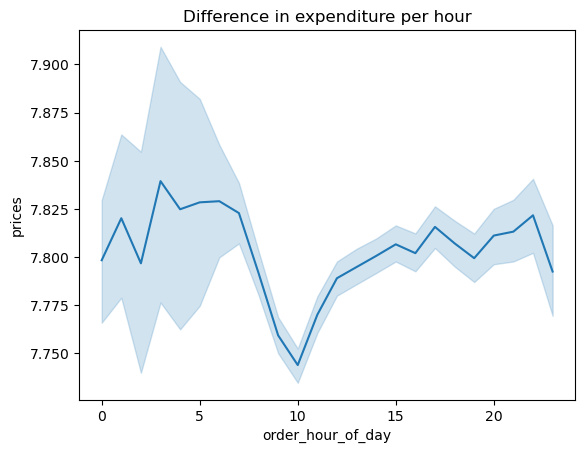

In [40]:
# Create line chart 
line_prices_hour = sns.lineplot(data=small, x='order_hour_of_day', y='prices')
plt.title('Difference in expenditure per hour')

plt.show()

This line chart shows the average prices of products purchased by hour of the day, along with a shaded confidence interval representing variability in the data. The trend indicates that prices are slightly higher during the early morning hours (around 12 AM to 6 AM), followed by a noticeable decline as the day progresses. The lowest average prices occur around mid-morning to early afternoon (approximately 10 AM to 2 PM), after which prices gradually increase again toward the evening hours. 

The confidence intervals indicate some variability, particularly during the early morning and late evening, which could suggest fewer data points or greater fluctuations in spending patterns during these times. Overall, the chart reveals subtle differences in expenditure throughout the day.

# 05. Customers visualizations

### Import customer data

The visualization are only for customers so I am going to use the clean customer data as the customer data merged with orders and products is to big.

In [45]:
# Export customer data 
customer_data = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared data', 'customer_data.pkl'))

In [46]:
customer_data.head()

,user_id,first_name,last_name,gender,state,age,date_joined,n_dependants,fam_status,income
0,26711,Deborah,Esquivel,Female,Missouri,48,1/1/2017,3,married,165665
1,33890,Patricia,Hart,Female,New Mexico,36,1/1/2017,0,single,59285
2,65803,Kenneth,Farley,Male,Idaho,35,1/1/2017,2,married,99568
3,125935,Michelle,Hicks,Female,Iowa,40,1/1/2017,0,single,42049
4,130797,Ann,Gilmore,Female,Maryland,26,1/1/2017,1,married,40374


In [47]:
customer_data.shape

(206209, 10)

### Customer demographics. Connection between age and family situation

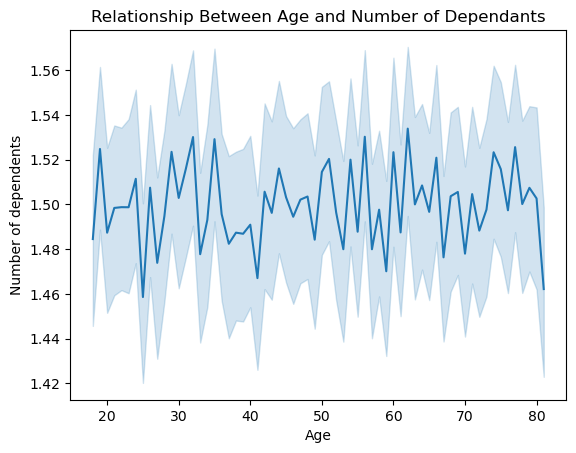

In [49]:
# Create a line chart to explore the connection between age and family situation
line_family_age = sns.lineplot(data=customer_data, x='age', y='n_dependants')
plt.title('Relationship Between Age and Number of Dependants')
plt.xlabel('Age')
plt.ylabel('Number of dependents')
plt.show()

The line fluctuates significantly across ages without showing a clear relationship between age and the number of dependents. This suggests that there may not be a meaningful connection between these two variables.

The y-axis ranges only from approximately 1.42 to 1.56, indicating that the average number of dependents is fairly stable and doesn’t vary much across age groups.

The wide confidence intervals suggest significant variability within the data, which could be attributed to small sample sizes for certain age groups, noise in the data, or randomness due to the lack of a true relationship.

### Connection between age and spending power (income)

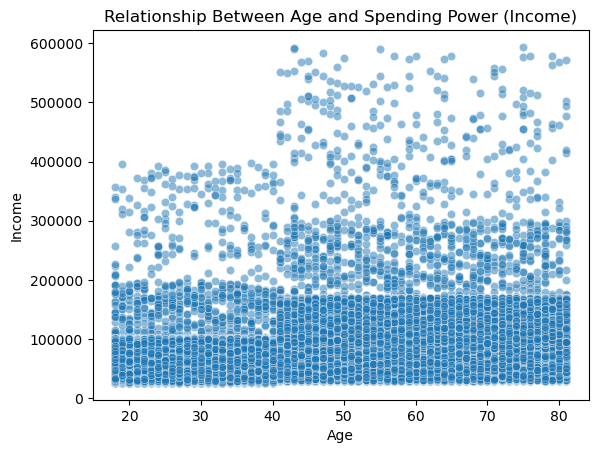

In [52]:
scatter_plot_spending = sns.scatterplot(data=customer_data, x='age', y='income', alpha=0.5)
plt.title('Relationship Between Age and Spending Power (Income)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

As we can see in the visualization younger customers (under 30) tend to have lower and more consistent incomes and older customers show a wider spread of income with some high earners. Even if the income increases with age there is no clear correlation line.

Most customers, regardless of age, cluster around below 100000 income. We can say that higher-income customers are a minority.


# 06. Export images

In [55]:
# Export histogram 
hist_order.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'hist_order.png'))

In [56]:
# Export loyalty bar chart
bar_loyalty.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_loyalty.png'))

In [57]:
# Export line chart price per hour
line_prices_hour.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_price_hour.png'))

In [58]:
# Export line chart connection family and age
line_family_age.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_family_age.png'))

In [59]:
# Export scatter plot spending per age 
scatter_plot_spending.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'scatter_plot_spending.png'))

In [102]:
bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_days.png'))